# 🌿 PlantGuard AI — Plant Disease Predictor
Run each cell one by one. No backend or frontend needed.

In [3]:
# ── Cell 1: Install dependencies (run once) ──
import sys
!{sys.executable} -m pip install tensorflow pillow numpy --quiet

In [4]:
# ── Cell 2: Load the model ──
import os, numpy as np
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
import tensorflow as tf
from PIL import Image

CLASS_LABELS = [
    "Apple › Apple Scab", "Apple › Black Rot", "Apple › Cedar Apple Rust", "Apple › Healthy",
    "Blueberry › Healthy", "Cherry › Powdery Mildew", "Cherry › Healthy",
    "Corn › Cercospora Leaf Spot", "Corn › Common Rust", "Corn › Northern Leaf Blight", "Corn › Healthy",
    "Grape › Black Rot", "Grape › Esca", "Grape › Leaf Blight", "Grape › Healthy",
    "Orange › Haunglongbing",
    "Peach › Bacterial Spot", "Peach › Healthy",
    "Pepper Bell › Bacterial Spot", "Pepper Bell › Healthy",
    "Potato › Early Blight", "Potato › Late Blight", "Potato › Healthy",
    "Raspberry › Healthy", "Soybean › Healthy", "Squash › Powdery Mildew",
    "Strawberry › Leaf Scorch", "Strawberry › Healthy",
    "Tomato › Bacterial Spot", "Tomato › Early Blight", "Tomato › Late Blight",
    "Tomato › Leaf Mold", "Tomato › Septoria Leaf Spot", "Tomato › Spider Mites",
    "Tomato › Target Spot", "Tomato › Yellow Leaf Curl Virus",
    "Tomato › Mosaic Virus", "Tomato › Healthy",
]

# ⚠️ Update this path if your model is elsewhere
MODEL_PATH = r"C:\ezyZip\backend\model\model.h5"

# Build model architecture and load weights
model = tf.keras.Sequential([
    tf.keras.Input(shape=(64, 64, 3)),
    tf.keras.layers.Conv2D(64, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2, 2),
    tf.keras.layers.Conv2D(64, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2, 2),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(38, activation='softmax'),
])
model.load_weights(MODEL_PATH)
print('✅ Model loaded successfully!')

✅ Model loaded successfully!


In [5]:
# ── Cell 3: Predict function ──
import matplotlib.pyplot as plt

def predict(image_path):
    # Load & preprocess
    img = Image.open(image_path).convert('RGB').resize((64, 64))
    arr = np.expand_dims(np.array(img, dtype=np.float32) / 255.0, axis=0)
    preds = model.predict(arr, verbose=0)[0]

    confidence = float(np.max(preds))
    top3_idx = np.argsort(preds)[::-1][:3]

    # Show image
    plt.figure(figsize=(4, 4))
    plt.imshow(Image.open(image_path))
    plt.axis('off')
    plt.title('Input Leaf Image')
    plt.show()

    # Results
    if confidence < 0.60:
        print('❌ Not a plant image or unrecognized leaf (confidence too low)')
        print(f'   Confidence: {confidence*100:.1f}%')
        return

    print('=' * 50)
    print(f'🌿 PREDICTION RESULT')
    print('=' * 50)
    top_label = CLASS_LABELS[top3_idx[0]]
    is_healthy = 'Healthy' in top_label
    print(f'  Disease  : {top_label}')
    print(f'  Confidence: {confidence*100:.1f}%')
    print(f'  Status   : {"✅ Healthy" if is_healthy else "🔴 Diseased"}')
    if confidence < 0.75:
        print(f'  ⚠️  Low confidence — try a clearer photo')
    print()
    print('📊 Top 3 Predictions:')
    for i, idx in enumerate(top3_idx):
        bar = '█' * int(preds[idx] * 30)
        print(f'  {i+1}. {CLASS_LABELS[idx]:<40} {preds[idx]*100:5.1f}%  {bar}')
    print('=' * 50)

print('✅ predict() function ready!')

✅ predict() function ready!


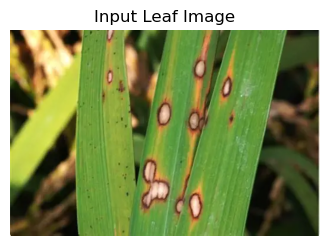

🌿 PREDICTION RESULT
  Disease  : Corn › Common Rust
  Confidence: 65.5%
  Status   : 🔴 Diseased
  ⚠️  Low confidence — try a clearer photo

📊 Top 3 Predictions:
  1. Corn › Common Rust                        65.5%  ███████████████████
  2. Corn › Cercospora Leaf Spot               25.0%  ███████
  3. Corn › Northern Leaf Blight                3.6%  █


In [6]:
# ── Cell 4: Run prediction ──
# 👇 Paste your image path below (no extra quotes)
IMAGE_PATH = r"C:\Users\tarun\Downloads\OIP.webp"

predict(IMAGE_PATH)

In [7]:
# ── Cell 5 (Optional): Pick image with file dialog ──
import tkinter as tk
from tkinter import filedialog

root = tk.Tk()
root.withdraw()
image_path = filedialog.askopenfilename(
    title='Select a leaf image',
    filetypes=[('Image files', '*.jpg *.jpeg *.png *.webp *.bmp')]
)
root.destroy()

if image_path:
    predict(image_path)
else:
    print('No file selected.')

No file selected.
